# BTC / NQ Correlation Strategy — Parameter Optimization
**Methodology:** Staged grid search | 70 / 30 chronological split | Rule-based only

Each stage fixes the best parameters found in the previous stage and optimises one layer at a time:
1. Signal — correlation gate + synchronized momentum
2. Exit — hold limits and trailing stop
3. Filters — intraday trend gates, daily cap, post-loss cooldown
4. Sizing — volatility-targeted contract count

The 30 % test set is touched exactly once, in the final cell.

## Section 0 — Configuration

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ---------------------------------------------------------------------------
# FILE PATHS  — edit these before running
# ---------------------------------------------------------------------------
FILE_NQ  = r"C:\Python\algo\data\NQ_stitched_1min_2024-03-07_to_2026-03-07.csv"
FILE_BTC = r"C:\Python\studia\quant_connect\Correlation_Regime_Strategy\new\BTCUSDT_1m_2024-03-07_to_2026-03-07.csv"

# ---------------------------------------------------------------------------
# TIMEZONE & SESSION
# ---------------------------------------------------------------------------
TZ_OFFSET_HOURS   = 1        # UTC+1 (Warsaw winter = CET)
SESSION_START_H   = 15       # 15:30 CET = 09:30 ET
SESSION_START_M   = 30
EOD_H             = 21       # hard EOD exit
EOD_M             = 55

# ---------------------------------------------------------------------------
# SIMULATION CONSTANTS (not optimised)
# ---------------------------------------------------------------------------
PENALTY_PER_CONTRACT = 1.5   # NQ pts per contract round-trip (spread + fees)
INITIAL_EQUITY       = 100_000

# ---------------------------------------------------------------------------
# DEFAULT PARAMETER SET
# Used when a stage is NOT currently being optimised.
# Starts with all protective filters disabled so Stage 1 measures raw signal.
# ---------------------------------------------------------------------------
DEFAULTS = dict(
    CORR_WINDOW        = 15,
    CORR_THRESHOLD     = 0.95,
    MOM_LOOKBACK       = 30,
    STD_THRESHOLD      = 2.0,
    MIN_HOLD_BARS      = 5,
    MAX_HOLD_BARS      = 60,
    TRAIL_ACTIVATE_PTS = 9999,   # disabled
    TRAIL_DISTANCE_PTS = 15,
    MAX_DAILY_TRADES   = 999,    # disabled
    LOSS_COOLDOWN_PTS  = 20,
    LOSS_COOLDOWN_BARS = 0,      # disabled
    TREND_SMA_BARS     = 0,      # disabled
    DOWNTREND_SMA_BARS = 0,      # disabled
    GAP_FILTER_PCT     = 0.002,
    COOLDOWN_BARS      = 10,
    VOL_TARGET         = 0.0,    # 0 = fixed contracts
    ATR_WINDOW         = 14,
    MIN_CONTRACTS      = 1,
    MAX_CONTRACTS      = 40,
    FIXED_CONTRACTS    = 1,
)

print("Configuration loaded.")
print(f"  NQ  : {FILE_NQ}")
print(f"  BTC : {FILE_BTC}")
print(f"  Session: {SESSION_START_H}:{SESSION_START_M:02d} - {EOD_H}:{EOD_M:02d} CET")


Configuration loaded.
  NQ  : C:\Python\algo\data\NQ_stitched_1min_2024-03-07_to_2026-03-07.csv
  BTC : C:\Python\studia\quant_connect\Correlation_Regime_Strategy\new\BTCUSDT_1m_2024-03-07_to_2026-03-07.csv
  Session: 15:30 - 21:55 CET


## Section 1 — Data Pipeline

In [62]:
def load_csv(path, suffix):
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = [c.strip().lower() for c in df.columns]

    # 1. Znalezienie właściwej kolumny czasu i strefy
    if 'open time' in df.columns:
        df = df.rename(columns={'open time': 'time'})
        tz_source = 'UTC'  # Binance
    elif 'date' in df.columns:
        df = df.rename(columns={'date': 'time'})
        tz_source = 'America/Chicago' # CME Globex (sesja od 17:00 to czas Centralny US)
    else:
        raise ValueError(f"Nie znaleziono kolumny czasu w pliku dla {suffix}")

    # Usuwamy 'close time', żeby nam nie dublowało kolumny czasu
    if 'close time' in df.columns:
        df = df.drop(columns=['close time'])

    # 2. Bezpieczne przypisanie sufiksów dla OHLC
    rename_dict = {}
    for c in ['open', 'high', 'low', 'close']:
        if c in df.columns:
            rename_dict[c] = f'{c}_{suffix}'
    df = df.rename(columns=rename_dict)

    req = ['time', f'open_{suffix}', f'high_{suffix}', f'low_{suffix}', f'close_{suffix}']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"{suffix}: missing columns {missing}. Got: {df.columns.tolist()}")

    # 3. Wyrównanie stref czasowych (Timezone Alignment) do polskiego czasu
    df['datetime'] = pd.to_datetime(df['time'])
    df['datetime'] = df['datetime'].dt.tz_localize(tz_source, ambiguous='NaT', nonexistent='NaT')
    df['datetime'] = df['datetime'].dt.tz_convert('Europe/Warsaw')
    
    # Pozbywamy się znacznika strefy, żeby merge(inner join) zadziałał
    df['datetime'] = df['datetime'].dt.tz_localize(None)

    # 4. Zostawienie tylko tego, co nas interesuje
    keep = ['datetime', f'open_{suffix}', f'high_{suffix}', f'low_{suffix}', f'close_{suffix}']
    df = df.dropna(subset=['datetime']) # na wypadek zmiany czasu zimowy/letni
    df = df[keep].set_index('datetime').sort_index()

    # Zamiana na liczby
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        
    return df

print("Loading NQ...")
df_nq  = load_csv(FILE_NQ,  'nq')
print(f"  {len(df_nq):,} rows | {df_nq.index.min().date()} to {df_nq.index.max().date()}")

print("Loading BTC...")
df_btc = load_csv(FILE_BTC, 'btc')
print(f"  {len(df_btc):,} rows | {df_btc.index.min().date()} to {df_btc.index.max().date()}")

print("Merging (inner join)...")
df = df_btc.join(df_nq, how='inner')
df = df[df.index.dayofweek < 5]          # drop weekends
df.dropna(inplace=True)
print(f"  {len(df):,} bars after merge + weekend filter")

# ── Derived columns ──────────────────────────────────────────────────────────
df['ret_btc'] = df['close_btc'].pct_change()
df['ret_nq']  = df['close_nq'].pct_change()
df['hour']    = df.index.hour
df['minute']  = df.index.minute
df['date']    = df.index.date

# ── Session / EOD flags ───────────────────────────────────────────────────────
in_sess = (
    (df.index.hour > SESSION_START_H) |
    ((df.index.hour == SESSION_START_H) & (df.index.minute >= SESSION_START_M))
) & (
    (df.index.hour < EOD_H) |
    ((df.index.hour == EOD_H) & (df.index.minute < EOD_M))
)
df['in_session'] = in_sess

eod = (df.index.hour > EOD_H) | (
    (df.index.hour == EOD_H) & (df.index.minute >= EOD_M)
)
df['eod'] = eod

# ── Gap bar flag ──────────────────────────────────────────────────────────────
prev_close_nq  = df['close_nq'].shift(1)
gap_pct        = (df['open_nq'] - prev_close_nq).abs() / prev_close_nq
df['is_gap_bar'] = gap_pct > DEFAULTS['GAP_FILTER_PCT']

# ── Post-session-open cooldown flag ──────────────────────────────────────────
time_gap_min = (
    df.index.to_series().diff().dt.total_seconds().div(60).fillna(0).values
)
is_open = time_gap_min > 60
counter = DEFAULTS['COOLDOWN_BARS'] + 1
bso = np.full(len(df), DEFAULTS['COOLDOWN_BARS'] + 1, dtype=int)
for i in range(len(df)):
    if is_open[i]:
        counter = 0
    bso[i]   = counter
    counter += 1
df['in_cooldown']      = bso < DEFAULTS['COOLDOWN_BARS']
df['signal_blocked']   = df['is_gap_bar'] | df['in_cooldown']

df.dropna(inplace=True)
print(f"  {len(df):,} bars after feature engineering")

# ==========================================================
# --- RENTGEN 2.0: GDZIE GINĄ SYGNAŁY? ---
    # ==========================================================
print("\n--- RENTGEN 2.0 (FILTRY) ---")
    
temp_corr = df['ret_btc'].rolling(15).corr(df['ret_nq'])
temp_z_btc = df['close_btc'].pct_change(30) / df['ret_btc'].rolling(30).std(ddof=1)
temp_z_nq = df['close_nq'].pct_change(30) / df['ret_nq'].rolling(30).std(ddof=1)
    
long_signals = (temp_z_btc > 2.0) & (temp_z_nq > 2.0) & (temp_corr >= 0.95)
print(f"1. Surowe sygnały LONG (bez filtrów): {long_signals.sum()}")
    
in_sess_signals = long_signals & df['in_session']
print(f"2. Z tego, ile wystąpiło W TRAKCIE SESJI (15:30-21:55 CET): {in_sess_signals.sum()}")
    
unblocked_signals = in_sess_signals & ~df['signal_blocked']
print(f"3. Po odrzuceniu blokady luk i cooldownu startowego: {unblocked_signals.sum()}")
print("==========================================================\n")

# ── 70 / 30 chronological split ───────────────────────────────────────────────
split_i   = int(len(df) * 0.70)
train_df  = df.iloc[:split_i].copy()
test_df   = df.iloc[split_i:].copy()

print()
print(f"{'TRAIN (70%)':<20} {len(train_df):>8,} bars | {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"{'TEST  (30%)':<20} {len(test_df):>8,} bars | {test_df.index[0].date()} to {test_df.index[-1].date()}")
print()
print("The test set is NOT touched until Section 9.")


Loading NQ...
  682,063 rows | 2024-03-08 to 2026-03-06
Loading BTC...
  1,051,201 rows | 2024-03-07 to 2026-03-07
Merging (inner join)...
  681,583 bars after merge + weekend filter
  681,582 bars after feature engineering

--- RENTGEN 2.0 (FILTRY) ---
1. Surowe sygnały LONG (bez filtrów): 298
2. Z tego, ile wystąpiło W TRAKCIE SESJI (15:30-21:55 CET): 38
3. Po odrzuceniu blokady luk i cooldownu startowego: 37


TRAIN (70%)           477,107 bars | 2024-03-08 to 2025-08-04
TEST  (30%)           204,475 bars | 2025-08-04 to 2026-03-06

The test set is NOT touched until Section 9.


## Section 2 — Pre-computation Library

All rolling indicators needed by the grid searches are computed once here and cached as numpy arrays. The simulation loops only do lookups — no pandas during the hot path.

In [63]:
# Values for which we pre-compute arrays
CORR_WINDOWS_ALL    = [10, 15, 20, 30]
MOM_LOOKBACKS_ALL   = [10, 15, 20, 30, 45]
SMA_BARS_ALL        = [0, 30, 60, 100, 120, 200]     # 0 = disabled sentinel
ATR_WINDOWS_ALL     = [10, 14, 20]


def build_indicator_library(df):
    """
    Returns a dict of numpy arrays pre-computed for all grid parameter values.
    """
    lib = {}
    n   = len(df)

    # -- Base arrays ----------------------------------------------------------
    lib['n']              = n
    lib['open_nq']        = df['open_nq'].values.astype(float)
    lib['close_nq']       = df['close_nq'].values.astype(float)
    lib['high_nq']        = df['high_nq'].values.astype(float)
    lib['low_nq']         = df['low_nq'].values.astype(float)
    lib['open_btc']       = df['open_btc'].values.astype(float)
    lib['close_btc']      = df['close_btc'].values.astype(float)
    lib['in_session']     = df['in_session'].values
    lib['eod']            = df['eod'].values
    lib['signal_blocked'] = df['signal_blocked'].values
    lib['dates']          = np.array(df['date'].values)

    # -- Correlation arrays ---------------------------------------------------
    print("Pre-computing correlation arrays...", end=' ')
    for w in CORR_WINDOWS_ALL:
        # Używamy bezpośrednio df, aby zachować wspólny indeks
        s = df['ret_btc'].rolling(w).corr(df['ret_nq'])
        lib[f'corr_{w}'] = s.values.astype(float)
    print("done")

    # -- Z-score arrays -------------------------------------------------------
    print("Pre-computing z-score arrays...", end=' ')
    for L in MOM_LOOKBACKS_ALL:
        cum_btc = df['close_btc'].pct_change(L)
        cum_nq  = df['close_nq'].pct_change(L)
        
        # Używamy df['ret_btc'] zamiast roboczego pd.Series, by zachować daty!
        std_b   = df['ret_btc'].rolling(L).std(ddof=1)
        std_n   = df['ret_nq'].rolling(L).std(ddof=1)
        
        z_btc_series = cum_btc / std_b.replace(0, np.nan)
        z_nq_series  = cum_nq / std_n.replace(0, np.nan)
        
        lib[f'z_btc_{L}'] = z_btc_series.values.astype(float)
        lib[f'z_nq_{L}']  = z_nq_series.values.astype(float)
    print("done")

    # -- SMA arrays -----------------------------------------------------------
    print("Pre-computing SMA arrays...", end=' ')
    for s in SMA_BARS_ALL:
        if s == 0:
            lib['sma_0'] = np.full(n, np.nan)   # gate disabled
        else:
            lib[f'sma_{s}'] = df['close_nq'].rolling(s).mean().values.astype(float)
    print("done")

    # -- ATR arrays -----------------------------------------------------------
    print("Pre-computing ATR arrays...", end=' ')
    prev_c = df['close_nq'].shift(1)
    tr     = pd.concat([
        df['high_nq'] - df['low_nq'],
        (df['high_nq'] - prev_c).abs(),
        (df['low_nq']  - prev_c).abs(),
    ], axis=1).max(axis=1)
    for a in ATR_WINDOWS_ALL:
        lib[f'atr_{a}'] = tr.rolling(a).mean().values.astype(float)
    print("done")

    return lib


print("Building train library...")
train_lib = build_indicator_library(train_df)
print(f"  {train_lib['n']:,} bars, {len(train_lib)} arrays cached")


Building train library...
Pre-computing correlation arrays... done
Pre-computing z-score arrays... done
Pre-computing SMA arrays... done
Pre-computing ATR arrays... done
  477,107 bars, 34 arrays cached


## Section 3 — Simulation Engine

Single function that runs a full sequential backtest given any parameter combination. No pandas in the hot path — pure numpy array lookups.

In [64]:
def simulate(lib, p):
    """
    Full sequential backtest.

    lib : pre-computed indicator library (from build_indicator_library)
    p   : parameter dict (must contain all keys in DEFAULTS)

    Returns
    -------
    list of trade dicts with keys:
        entry_bar, exit_bar, direction, entry_price, exit_price,
        pnl_pts, pnl_net, n_contracts, bars_held, reason
    """
    n = lib['n']

    # Unpack indicator arrays
    corr_arr   = lib[f'corr_{p["CORR_WINDOW"]}']
    z_btc_arr  = lib[f'z_btc_{p["MOM_LOOKBACK"]}']
    z_nq_arr   = lib[f'z_nq_{p["MOM_LOOKBACK"]}']
    sma_f_arr  = lib[f'sma_{p["TREND_SMA_BARS"]}']
    sma_s_arr  = lib[f'sma_{p["DOWNTREND_SMA_BARS"]}']
    atr_arr    = lib[f'atr_{p["ATR_WINDOW"]}']

    open_nq  = lib['open_nq'];  close_nq  = lib['close_nq']
    high_nq  = lib['high_nq'];  low_nq    = lib['low_nq']
    open_btc = lib['open_btc']; close_btc = lib['close_btc']
    in_sess  = lib['in_session']
    eod      = lib['eod']
    blocked  = lib['signal_blocked']
    dates    = lib['dates']

    # Trade state
    in_trade     = False
    direction    = 0
    entry_price  = 0.0
    peak_price   = 0.0
    trail_active = False
    bars_held    = 0
    n_contr      = 1
    entry_bar    = 0

    # Daily state
    daily_count  = 0
    current_date = None

    # Post-loss cooldown
    bars_since_loss = p['LOSS_COOLDOWN_BARS'] + 1

    equity = 0.0
    trades = []

    i = 0
    while i < n:
        # ── Daily reset ───────────────────────────────────────────────────────
        today = dates[i]
        if today != current_date:
            current_date = today
            daily_count  = 0

        # ── Increment post-loss counter ───────────────────────────────────────
        bars_since_loss = min(bars_since_loss + 1, p['LOSS_COOLDOWN_BARS'] + 1)

        # ── Position management ───────────────────────────────────────────────
        if in_trade:
            bars_held += 1
            c_price   = close_nq[i]
            unreal    = (c_price - entry_price) * direction

            # Update peak
            if direction == 1:
                if c_price > peak_price:
                    peak_price = c_price
            else:
                if c_price < peak_price:
                    peak_price = c_price

            peak_unreal = abs(peak_price - entry_price)

            # Activate trailing stop
            if not trail_active and unreal >= p['TRAIL_ACTIVATE_PTS']:
                trail_active = True

            # ── Exit checks (priority order) ──────────────────────────────────
            exit_reason = None
            exit_px     = None

            if eod[i]:
                exit_reason = 'EOD'
                exit_px     = open_nq[i]

            elif bars_held >= p['MAX_HOLD_BARS']:
                exit_reason = 'MaxHold'
                exit_px     = close_nq[i]

            elif trail_active and bars_held >= p['MIN_HOLD_BARS']:
                dd_from_peak = peak_unreal - unreal
                if dd_from_peak >= p['TRAIL_DISTANCE_PTS']:
                    exit_reason = 'Trail'
                    exit_px     = open_nq[i + 1] if i + 1 < n else close_nq[i]

            elif bars_held >= p['MIN_HOLD_BARS']:
                d_btc = np.sign(close_btc[i] - open_btc[i])
                d_nq  = np.sign(close_nq[i]  - open_nq[i])
                if (d_btc == -direction and d_nq == -direction):
                    exit_reason = 'Reversal'
                    exit_px     = open_nq[i + 1] if i + 1 < n else close_nq[i]
                elif (d_btc != 0 and d_nq != 0 and d_btc != d_nq):
                    exit_reason = 'Divergence'
                    exit_px     = open_nq[i + 1] if i + 1 < n else close_nq[i]

            if exit_reason:
                pnl_pts = (exit_px - entry_price) * direction
                pnl_net = pnl_pts * n_contr - PENALTY_PER_CONTRACT * n_contr
                equity += pnl_net

                if pnl_pts < -p['LOSS_COOLDOWN_PTS']:
                    bars_since_loss = 0

                trades.append(dict(
                    entry_bar   = entry_bar,
                    exit_bar    = i,
                    direction   = direction,
                    entry_price = entry_price,
                    exit_price  = exit_px,
                    pnl_pts     = pnl_pts,
                    pnl_net     = pnl_net,  
                    n_contracts = n_contr,
                    bars_held   = bars_held,
                    reason      = exit_reason,
                ))

                in_trade  = False
                direction = 0
                bars_held = 0

            i += 1
            continue

        # ── Signal generation ─────────────────────────────────────────────────
        if not in_sess[i]:
            i += 1; continue
        if blocked[i]:
            i += 1; continue
        if daily_count >= p['MAX_DAILY_TRADES']:
            i += 1; continue
        if bars_since_loss <= p['LOSS_COOLDOWN_BARS']:
            i += 1; continue

        corr  = corr_arr[i]
        z_btc = z_btc_arr[i]
        z_nq  = z_nq_arr[i]

        if np.isnan(corr) or np.isnan(z_btc) or np.isnan(z_nq):
            i += 1; continue
        if corr < p['CORR_THRESHOLD']:
            i += 1; continue

        thr = p['STD_THRESHOLD']
        long_sig  = z_btc > thr and z_nq > thr
        short_sig = z_btc < -thr and z_nq < -thr

        if not (long_sig or short_sig):
            i += 1; continue

        dir_cand = 1 if long_sig else -1

        # Trend gates
        if p['TREND_SMA_BARS'] > 0:
            sf = sma_f_arr[i]
            if not np.isnan(sf) and dir_cand == 1 and close_nq[i] < sf:
                i += 1; continue
        if p['DOWNTREND_SMA_BARS'] > 0:
            ss = sma_s_arr[i]
            if not np.isnan(ss) and dir_cand == -1 and close_nq[i] > ss:
                i += 1; continue

        # Entry bar is i+1
        eb = i + 1
        if eb >= n:
            i += 1; continue

        # Position sizing
        if p['VOL_TARGET'] > 0:
            atr_v = atr_arr[i]
            if not np.isnan(atr_v) and atr_v > 0:
                eq_v  = INITIAL_EQUITY + equity
                n_c   = int(eq_v * p['VOL_TARGET'] / (atr_v * 2))
                n_c   = max(p['MIN_CONTRACTS'], min(p['MAX_CONTRACTS'], n_c))
            else:
                n_c = p['FIXED_CONTRACTS']
        else:
            n_c = p['FIXED_CONTRACTS']

        # Enter
        in_trade     = True
        direction    = dir_cand
        entry_price  = open_nq[eb]
        peak_price   = entry_price
        trail_active = False
        bars_held    = 0
        n_contr      = n_c
        entry_bar    = eb
        daily_count += 1

        i = eb   # advance to entry bar (position management starts next iter)

    return trades


def metrics(trades):
    """Compute performance metrics from a list of trade dicts."""
    if len(trades) < 5:
        return dict(n=len(trades), wr=np.nan, avg=np.nan, sharpe=np.nan,
                    pf=np.nan, total=np.nan, avg_dur=np.nan, max_dd=np.nan)
    net  = np.array([t['pnl_net'] for t in trades])
    durs = np.array([t['bars_held'] for t in trades])
    wins = net[net > 0].sum()
    loss = net[net <= 0].sum()
    std  = net.std(ddof=1)
    eq   = np.cumsum(np.concatenate([[0], net]))
    peak = np.maximum.accumulate(eq)
    mdd  = (eq - peak).min()
    return dict(
        n       = len(net),
        wr      = float((net > 0).mean()),
        avg     = float(net.mean()),
        sharpe  = float(net.mean() / std) if std > 0 else np.nan,
        pf      = float(wins / abs(loss)) if loss != 0 else np.nan,
        total   = float(net.sum()),
        avg_dur = float(durs.mean()),
        max_dd  = float(mdd),
    )


# Smoke test
_p = dict(DEFAULTS)
_tr = simulate(train_lib, _p)
_m  = metrics(_tr)
print(f"Smoke test (defaults): n={_m['n']}  sharpe={_m['sharpe']:.3f}  total={_m['total']:.1f} pts")


Smoke test (defaults): n=21  sharpe=0.155  total=691.5 pts


## Section 4 — Stage 1: Signal Parameters

Optimise the four parameters that define *when* a signal is generated.
All protective filters remain disabled so we measure raw signal quality only.

| Parameter | Grid |
|-----------|------|
| `CORR_WINDOW` | 10, 15, 20, 30 |
| `CORR_THRESHOLD` | 0.85, 0.90, 0.93, 0.95 |
| `MOM_LOOKBACK` | 10, 15, 20, 30, 45 |
| `STD_THRESHOLD` | 1.5, 2.0, 2.5, 3.0 |

Total: 4 x 4 x 5 x 4 = 320 combinations. Acceptance gate: n >= 20, Sharpe > 0.

In [72]:
from itertools import product

CORR_WINDOWS     = [10, 15, 20, 30]
CORR_THRESHOLDS  = [0.85, 0.90, 0.93, 0.95]
MOM_LOOKBACKS    = [10, 15, 20, 30, 45]
STD_THRESHOLDS   = [1.5, 2.0, 2.5, 3.0]

stage1_rows = []
combos = list(product(CORR_WINDOWS, CORR_THRESHOLDS, MOM_LOOKBACKS, STD_THRESHOLDS))
total  = len(combos)

for k, (cw, ct, ml, st) in enumerate(combos):
    p = dict(DEFAULTS, CORR_WINDOW=cw, CORR_THRESHOLD=ct, MOM_LOOKBACK=ml, STD_THRESHOLD=st)
    m = metrics(simulate(train_lib, p))
    stage1_rows.append(dict(
        CORR_WINDOW=cw, CORR_THRESHOLD=ct, MOM_LOOKBACK=ml, STD_THRESHOLD=st, **m
    ))
    if (k + 1) % 1 == 0 or k + 1 == total:
        print(f"  [{k+1:3d}/{total}]  last: corr({cw},{ct:.2f}) mom({ml},{st:.1f}) "
              f"-> n={m['n']} sharpe={m['sharpe']:+.3f}")

stage1_df = pd.DataFrame(stage1_rows)
passing   = stage1_df[(stage1_df['n'] >= 20) & (stage1_df['sharpe'] > 0)].copy()
passing   = passing.sort_values('sharpe', ascending=False).reset_index(drop=True)

print(f"\n{len(passing)} / {total} combinations passed acceptance gate (n>=20, Sharpe>0)")
print("\nTop 10:")
print(passing.head(10)[['CORR_WINDOW','CORR_THRESHOLD','MOM_LOOKBACK','STD_THRESHOLD',
                         'n','wr','avg','sharpe','pf','avg_dur']].to_string(index=False))


  [  1/320]  last: corr(10,0.85) mom(10,1.5) -> n=945 sharpe=-0.035
  [  2/320]  last: corr(10,0.85) mom(10,2.0) -> n=745 sharpe=-0.024
  [  3/320]  last: corr(10,0.85) mom(10,2.5) -> n=556 sharpe=-0.041
  [  4/320]  last: corr(10,0.85) mom(10,3.0) -> n=409 sharpe=-0.121
  [  5/320]  last: corr(10,0.85) mom(15,1.5) -> n=1064 sharpe=-0.012
  [  6/320]  last: corr(10,0.85) mom(15,2.0) -> n=880 sharpe=-0.036
  [  7/320]  last: corr(10,0.85) mom(15,2.5) -> n=720 sharpe=-0.017
  [  8/320]  last: corr(10,0.85) mom(15,3.0) -> n=568 sharpe=-0.037
  [  9/320]  last: corr(10,0.85) mom(20,1.5) -> n=1092 sharpe=+0.001
  [ 10/320]  last: corr(10,0.85) mom(20,2.0) -> n=912 sharpe=+0.003
  [ 11/320]  last: corr(10,0.85) mom(20,2.5) -> n=772 sharpe=-0.017
  [ 12/320]  last: corr(10,0.85) mom(20,3.0) -> n=635 sharpe=-0.003
  [ 13/320]  last: corr(10,0.85) mom(30,1.5) -> n=1175 sharpe=-0.021
  [ 14/320]  last: corr(10,0.85) mom(30,2.0) -> n=1026 sharpe=-0.014
  [ 15/320]  last: corr(10,0.85) mom(30,2.5)

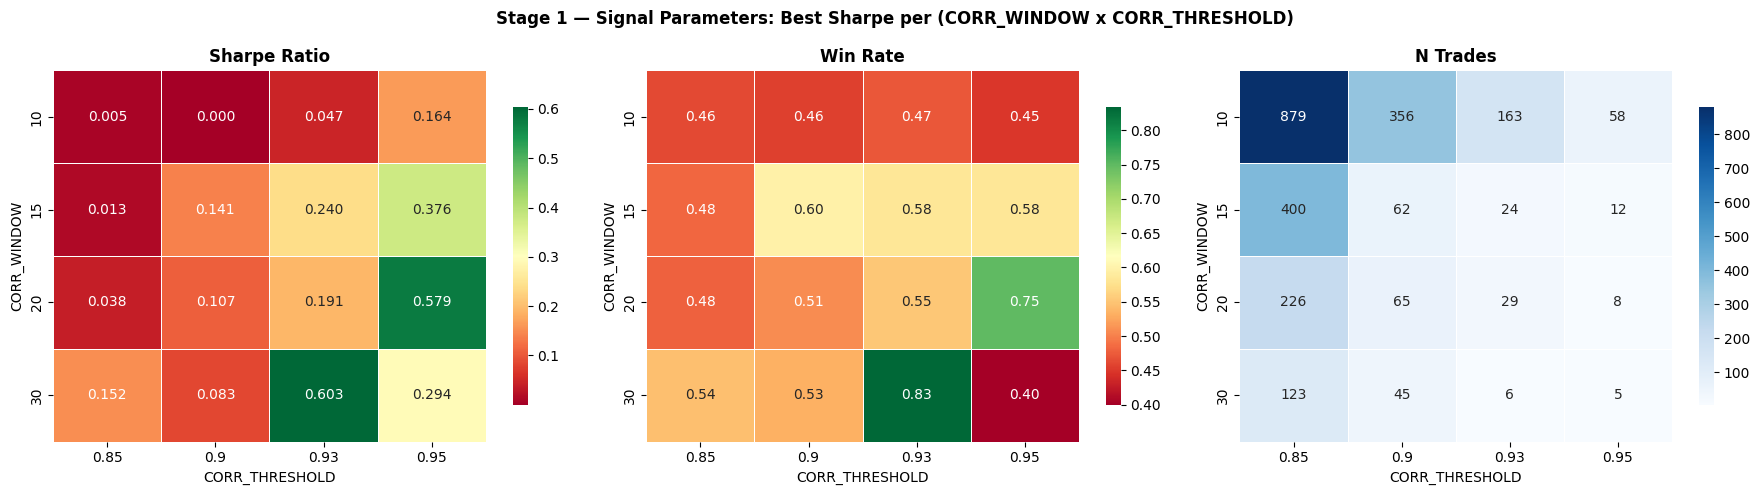

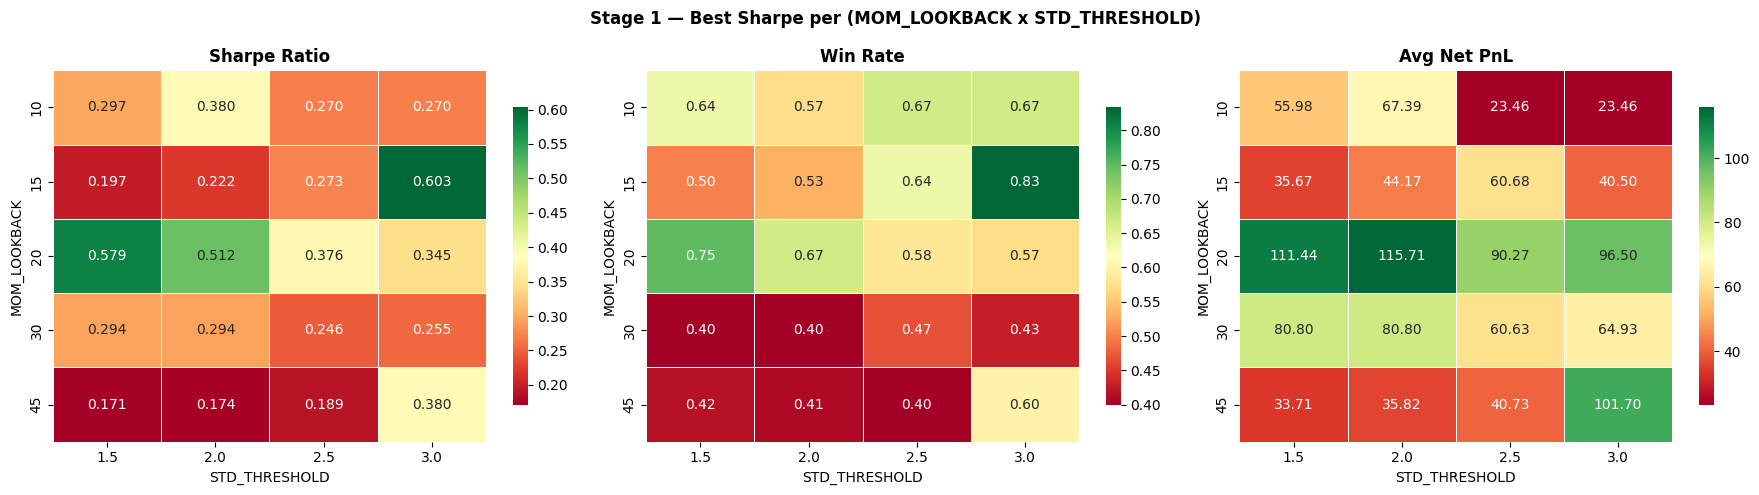

In [73]:
# Stage 1 heatmaps — best (MOM_LOOKBACK, STD_THRESHOLD) per (CORR_WINDOW, CORR_THRESHOLD)
best_s1 = (
    stage1_df.dropna(subset=['sharpe'])
             .sort_values('sharpe', ascending=False)
             .groupby(['CORR_WINDOW', 'CORR_THRESHOLD'], as_index=False)
             .first()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stage 1 — Signal Parameters: Best Sharpe per (CORR_WINDOW x CORR_THRESHOLD)',
             fontsize=12, fontweight='bold')
for ax, (col, title, fmt, cmap) in zip(axes, [
    ('sharpe', 'Sharpe Ratio',    '.3f', 'RdYlGn'),
    ('wr',     'Win Rate',        '.2f', 'RdYlGn'),
    ('n',      'N Trades',        '.0f', 'Blues'),
]):
    pivot = best_s1.pivot(index='CORR_WINDOW', columns='CORR_THRESHOLD', values=col)
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                linewidths=0.4, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('CORR_THRESHOLD')
    ax.set_ylabel('CORR_WINDOW')
plt.tight_layout()
plt.savefig('stage1_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Stage 1 — Best Sharpe per (MOM_LOOKBACK x STD_THRESHOLD)',
              fontsize=12, fontweight='bold')
best_s1b = (
    stage1_df.dropna(subset=['sharpe'])
             .sort_values('sharpe', ascending=False)
             .groupby(['MOM_LOOKBACK', 'STD_THRESHOLD'], as_index=False)
             .first()
)
for ax, (col, title, fmt, cmap) in zip(axes2, [
    ('sharpe', 'Sharpe Ratio', '.3f', 'RdYlGn'),
    ('wr',     'Win Rate',     '.2f', 'RdYlGn'),
    ('avg',    'Avg Net PnL',  '.2f', 'RdYlGn'),
]):
    pivot = best_s1b.pivot(index='MOM_LOOKBACK', columns='STD_THRESHOLD', values=col)
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                linewidths=0.4, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('STD_THRESHOLD')
    ax.set_ylabel('MOM_LOOKBACK')
plt.tight_layout()
plt.savefig('stage1_heatmaps_mom.png', dpi=120, bbox_inches='tight')
plt.show()


In [85]:
# Select best Stage 1 parameters
best_s1_row = passing.iloc[0]
BEST = dict(DEFAULTS)
for k in ['CORR_WINDOW', 'CORR_THRESHOLD', 'MOM_LOOKBACK', 'STD_THRESHOLD']:
    BEST[k] = best_s1_row[k]

print("=" * 55)
print("STAGE 1 RESULT — best signal parameters selected:")
print("=" * 55)
for k in ['CORR_WINDOW', 'CORR_THRESHOLD', 'MOM_LOOKBACK', 'STD_THRESHOLD']:
    print(f"  {k:<22} = {BEST[k]}")
print()
print(f"  In-sample Sharpe  : {best_s1_row['sharpe']:+.4f}")
print(f"  Win rate          : {best_s1_row['wr']*100:.1f}%")
print(f"  N trades          : {int(best_s1_row['n'])}")
print(f"  Avg PnL / trade   : {best_s1_row['avg']:+.2f} NQ pts")
print(f"  Profit factor     : {best_s1_row['pf']:.3f}")


STAGE 1 RESULT — best signal parameters selected:
  CORR_WINDOW            = 15.0
  CORR_THRESHOLD         = 0.95
  MOM_LOOKBACK           = 20.0
  STD_THRESHOLD          = 1.5

  In-sample Sharpe  : +0.3665
  Win rate          : 60.0%
  N trades          : 20
  Avg PnL / trade   : +73.80 NQ pts
  Profit factor     : 8.589


## Section 5 — Stage 2: Exit Parameters

Using best signal parameters from Stage 1. Optimise hold limits and trailing stop.

| Parameter | Grid |
|-----------|------|
| `MIN_HOLD_BARS` | 1, 2, 3, 4, 5, 6|
| `MAX_HOLD_BARS` | 60|
| `TRAIL_ACTIVATE_PTS` | 20, 30, 40 |
| `TRAIL_DISTANCE_PTS` | 10, 15, 20 |

In [93]:
from tqdm.notebook import tqdm

# OG: MIN_HOLD_GRID    = [3, 5, 8, 12]
MIN_HOLD_GRID    = [1, 2, 3, 4, 5, 6]
MAX_HOLD_GRID    = [60]
TRAIL_ACT_GRID   = [20, 30, 40]
TRAIL_DIST_GRID  = [10, 15, 20]

# --- NAPRAWA TYPÓW PANDAS (FLOAT -> INT) ---
BEST['CORR_WINDOW'] = int(BEST['CORR_WINDOW'])
BEST['MOM_LOOKBACK'] = int(BEST['MOM_LOOKBACK'])
if 'TREND_SMA_BARS' in BEST: BEST['TREND_SMA_BARS'] = int(BEST['TREND_SMA_BARS'])
if 'DOWNTREND_SMA_BARS' in BEST: BEST['DOWNTREND_SMA_BARS'] = int(BEST['DOWNTREND_SMA_BARS'])
if 'ATR_WINDOW' in BEST: BEST['ATR_WINDOW'] = int(BEST['ATR_WINDOW'])
# ------------------------------------------

stage2_rows = []
combos2 = list(product(MIN_HOLD_GRID, MAX_HOLD_GRID, TRAIL_ACT_GRID, TRAIL_DIST_GRID))

for mh, mxh, ta, td in tqdm(combos2, desc="Stage 2: Exits Optimization"):
    if mh >= mxh:
        continue   
        
    p = dict(BEST,
             MIN_HOLD_BARS=mh, MAX_HOLD_BARS=mxh,
             TRAIL_ACTIVATE_PTS=ta, TRAIL_DISTANCE_PTS=td)
             
    m = metrics(simulate(train_lib, p))
    
    n_tr = m['n']
    wr = m['wr']
    total = m['total']
    sharpe = m['sharpe']
    
    if n_tr > 0:
        # --- ROBUSTNESS SCORE Z ANALIZY WYKRESOWEJ ---
        # Wyrzucamy Profit Factor, bo sztucznie pompował wyniki (jak dla mh=3).
        # Teraz algorytm patrzy wyłącznie na: Total PnL * (Win Rate ^ 2).
        # Faworyzuje to stabilne, globalnie odporne warianty (jak mh=5).
        robustness = total * (wr ** 2)
        obj_score = robustness 
    else:
        robustness = 0
        obj_score = 0
        
    stage2_rows.append(dict(
        MIN_HOLD_BARS=mh, MAX_HOLD_BARS=mxh,
        TRAIL_ACTIVATE_PTS=ta, TRAIL_DISTANCE_PTS=td, 
        robustness=robustness, obj_score=obj_score, **m
    ))

stage2_df = pd.DataFrame(stage2_rows)

# =====================================================================
# DYNAMICZNY FALLBACK (BEZPIECZNIK PROGÓW)
# =====================================================================
passing2 = stage2_df[(stage2_df['n'] >= 20) & (stage2_df['sharpe'] > 0)].copy()

if passing2.empty:
    print("[WARN] Brak kombinacji z n >= 20. Obniżanie progu do n >= 10...")
    passing2 = stage2_df[(stage2_df['n'] >= 10) & (stage2_df['sharpe'] > 0)].copy()

if passing2.empty:
    print("[WARN] Brak kombinacji z n >= 10. Wybieranie wszystkiego z Sharpe > 0...")
    passing2 = stage2_df[stage2_df['sharpe'] > 0].copy()
    
if passing2.empty:
    print("[FATAL] Wszystkie kombinacje wygenerowały ujemne Sharpe. Wypisywanie czystych wyników:")
    passing2 = stage2_df.copy()
# =====================================================================

# Sortujemy po nowej metryce rzetelności
passing2 = passing2.sort_values('obj_score', ascending=False).reset_index(drop=True)

print(f"\n{len(passing2)} combinations passed filtering.")
print("\nTop 10 (Sorted by Trade Robustness: Total PnL * WR^2):")
print(passing2.head(10)[['MIN_HOLD_BARS','MAX_HOLD_BARS','TRAIL_ACTIVATE_PTS','TRAIL_DISTANCE_PTS',
                         'n','wr','total','sharpe','robustness']].to_string(index=False))

# Zapisujemy do słownika BEST
if not passing2.empty:
    best_s2_row = passing2.iloc[0]
    BEST['MIN_HOLD_BARS'] = int(best_s2_row['MIN_HOLD_BARS'])
    BEST['MAX_HOLD_BARS'] = int(best_s2_row['MAX_HOLD_BARS'])
    BEST['TRAIL_ACTIVATE_PTS'] = float(best_s2_row['TRAIL_ACTIVATE_PTS'])
    BEST['TRAIL_DISTANCE_PTS'] = float(best_s2_row['TRAIL_DISTANCE_PTS'])

Stage 2: Exits Optimization:   0%|          | 0/54 [00:00<?, ?it/s]


54 combinations passed filtering.

Top 10 (Sorted by Trade Robustness: Total PnL * WR^2):
 MIN_HOLD_BARS  MAX_HOLD_BARS  TRAIL_ACTIVATE_PTS  TRAIL_DISTANCE_PTS  n     wr     total  sharpe  robustness
             5             60                  30                  10 20 0.5500 1295.5000  0.3429    391.8888
             5             60                  40                  10 20 0.5500 1295.5000  0.3429    391.8888
             5             60                  40                  15 20 0.5500 1289.7500  0.3416    390.1494
             5             60                  30                  15 20 0.5500 1289.7500  0.3416    390.1494
             5             60                  40                  20 20 0.5500 1288.5000  0.3413    389.7713
             5             60                  30                  20 20 0.5500 1288.5000  0.3413    389.7713
             4             60                  30                  15 22 0.5455 1273.5000  0.3230    378.8926
             4             60

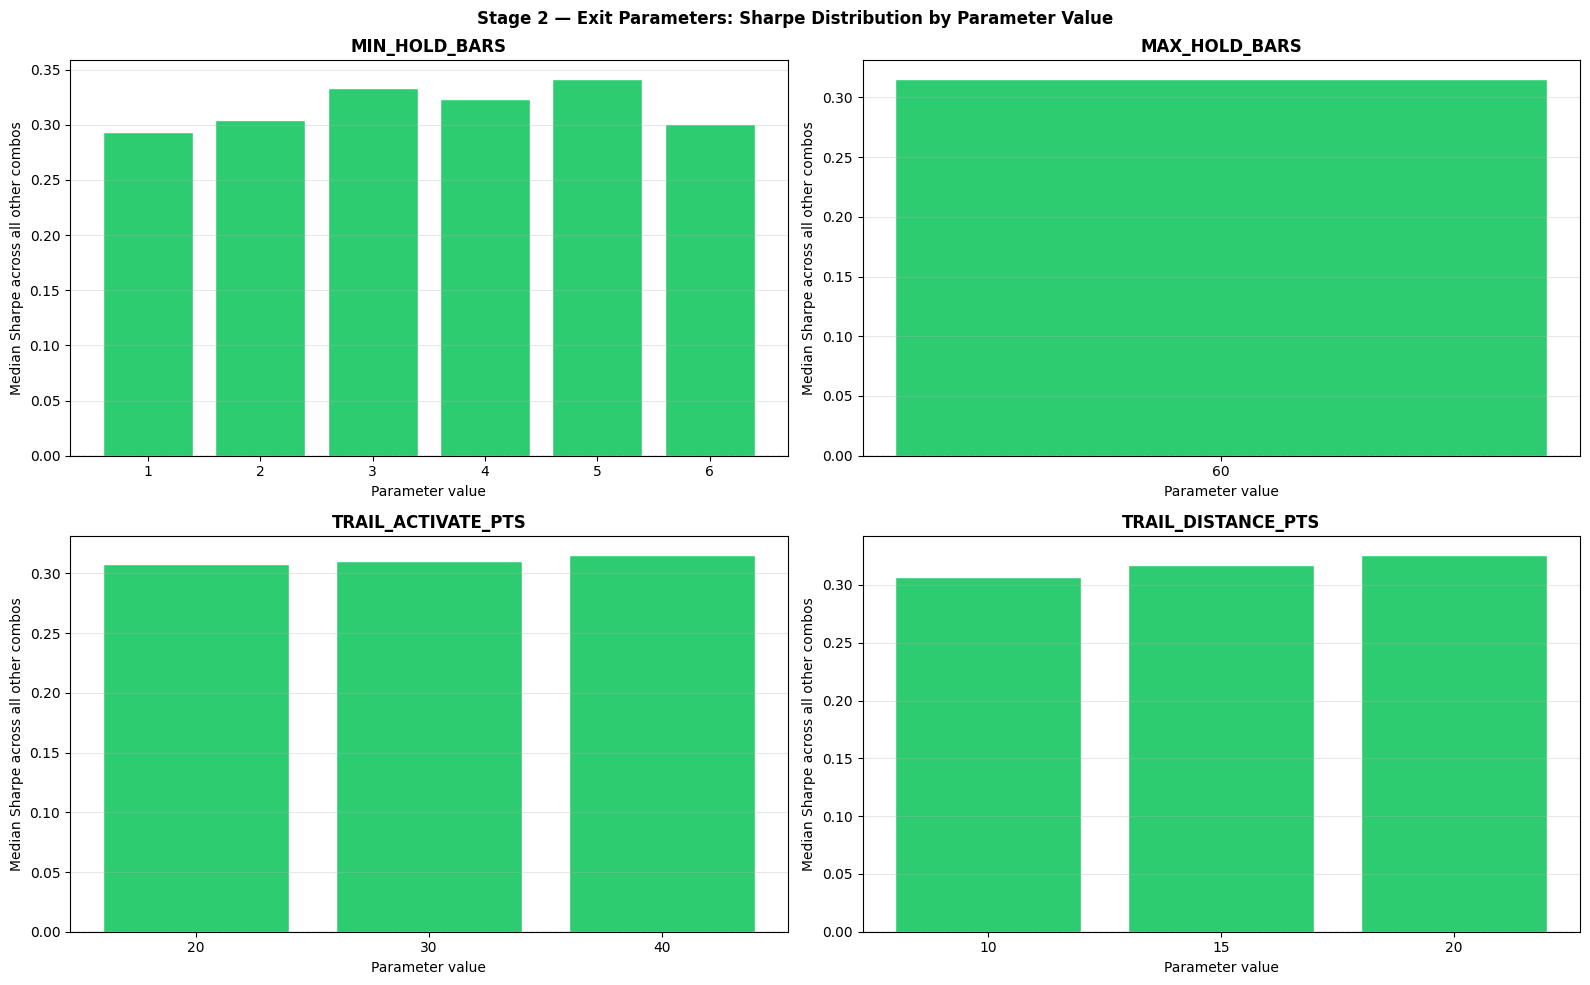

In [94]:
# Visualise exit parameter sensitivity
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 2 — Exit Parameters: Sharpe Distribution by Parameter Value',
             fontsize=12, fontweight='bold')

for ax, (param, title) in zip(axes.flat, [
    ('MIN_HOLD_BARS',    'MIN_HOLD_BARS'),
    ('MAX_HOLD_BARS',    'MAX_HOLD_BARS'),
    ('TRAIL_ACTIVATE_PTS', 'TRAIL_ACTIVATE_PTS'),
    ('TRAIL_DISTANCE_PTS', 'TRAIL_DISTANCE_PTS'),
]):
    vals = sorted(stage2_df[param].unique())
    medians = [stage2_df.loc[stage2_df[param]==v, 'sharpe'].median() for v in vals]
    colors  = ['#2ecc71' if v > 0 else '#e74c3c' for v in medians]
    ax.bar([str(v) for v in vals], medians, color=colors, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Median Sharpe across all other combos')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stage2_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()


In [95]:
# Select best Stage 2 parameters
best_s2_row = passing2.iloc[0]
for k in ['MIN_HOLD_BARS', 'MAX_HOLD_BARS', 'TRAIL_ACTIVATE_PTS', 'TRAIL_DISTANCE_PTS']:
    BEST[k] = best_s2_row[k]

print("=" * 55)
print("STAGE 2 RESULT — best exit parameters selected:")
print("=" * 55)
for k in ['MIN_HOLD_BARS', 'MAX_HOLD_BARS', 'TRAIL_ACTIVATE_PTS', 'TRAIL_DISTANCE_PTS']:
    print(f"  {k:<26} = {BEST[k]}")
print()
print(f"  In-sample Sharpe  : {best_s2_row['sharpe']:+.4f}")
print(f"  Avg hold (bars)   : {best_s2_row['avg_dur']:.1f}")
print(f"  Max drawdown      : {best_s2_row['max_dd']:.1f} NQ pts")


STAGE 2 RESULT — best exit parameters selected:
  MIN_HOLD_BARS              = 5.0
  MAX_HOLD_BARS              = 60.0
  TRAIL_ACTIVATE_PTS         = 30.0
  TRAIL_DISTANCE_PTS         = 10.0

  In-sample Sharpe  : +0.3429
  Avg hold (bars)   : 6.8
  Max drawdown      : -114.8 NQ pts


## Section 6 — Stage 3: Filter Parameters

Using best signal + exit parameters. Optimise protective filters.

| Parameter | Grid |
|-----------|------|
| `TREND_SMA_BARS` | 30, 60, 120, 200 |
| `DOWNTREND_SMA_BARS` | 100, 120, 200 |
| `MAX_DAILY_TRADES` | 3 |
| `LOSS_COOLDOWN_BARS` | 15, 30 |
| `LOSS_COOLDOWN_PTS` | 10, 20, 30 |

In [98]:
TREND_SMA_GRID  = [30, 60, 120, 200]
DOWN_SMA_GRID   = [100, 120, 200]
MAX_DAILY_GRID  = [3]
LOSS_CD_B_GRID  = [15, 30]
LOSS_CD_P_GRID  = [10, 20, 30]

stage3_rows = []
combos3 = list(product(TREND_SMA_GRID, DOWN_SMA_GRID, MAX_DAILY_GRID, LOSS_CD_B_GRID, LOSS_CD_P_GRID))
total3  = len(combos3)

for k, (ts, ds, md_, lcd_b, lcd_p) in enumerate(combos3):
    p = dict(BEST,
             TREND_SMA_BARS=ts, DOWNTREND_SMA_BARS=ds,
             MAX_DAILY_TRADES=md_,
             LOSS_COOLDOWN_BARS=lcd_b, LOSS_COOLDOWN_PTS=lcd_p)
    m = metrics(simulate(train_lib, p))
    stage3_rows.append(dict(
        TREND_SMA_BARS=ts, DOWNTREND_SMA_BARS=ds,
        MAX_DAILY_TRADES=md_, LOSS_COOLDOWN_BARS=lcd_b, LOSS_COOLDOWN_PTS=lcd_p, **m
    ))
    if (k + 1) % 60 == 0 or k + 1 == total3:
        print(f"  [{k+1:3d}/{total3}]  ts={ts} ds={ds} md={md_} cd=({lcd_b},{lcd_p}) "
              f"-> n={m['n']} sharpe={m['sharpe']:+.3f}")

stage3_df = pd.DataFrame(stage3_rows)
passing3  = stage3_df[(stage3_df['n'] >= 10) & (stage3_df['sharpe'] > 0)].copy()
passing3  = passing3.sort_values('sharpe', ascending=False).reset_index(drop=True)

print(f"\n{len(passing3)} / {len(stage3_df)} combinations passed (n>=10, Sharpe>0)")
print("\nTop 10:")
print(passing3.head(10)[['TREND_SMA_BARS','DOWNTREND_SMA_BARS','MAX_DAILY_TRADES',
                          'LOSS_COOLDOWN_BARS','LOSS_COOLDOWN_PTS',
                          'n','wr','sharpe','max_dd']].to_string(index=False))


  [ 60/72]  ts=200 ds=100 md=3 cd=(30,30) -> n=15 sharpe=+0.317
  [ 72/72]  ts=200 ds=200 md=3 cd=(30,30) -> n=14 sharpe=+0.342

72 / 72 combinations passed (n>=10, Sharpe>0)

Top 10:
 TREND_SMA_BARS  DOWNTREND_SMA_BARS  MAX_DAILY_TRADES  LOSS_COOLDOWN_BARS  LOSS_COOLDOWN_PTS  n     wr  sharpe   max_dd
            120                 200                 3                  15                 20 13 0.5385  0.4073 -99.7500
            120                 200                 3                  15                 10 13 0.5385  0.4073 -99.7500
            120                 200                 3                  30                 10 13 0.5385  0.4073 -99.7500
            120                 200                 3                  15                 30 13 0.5385  0.4073 -99.7500
            120                 200                 3                  30                 30 13 0.5385  0.4073 -99.7500
            120                 200                 3                  30                 20 13 

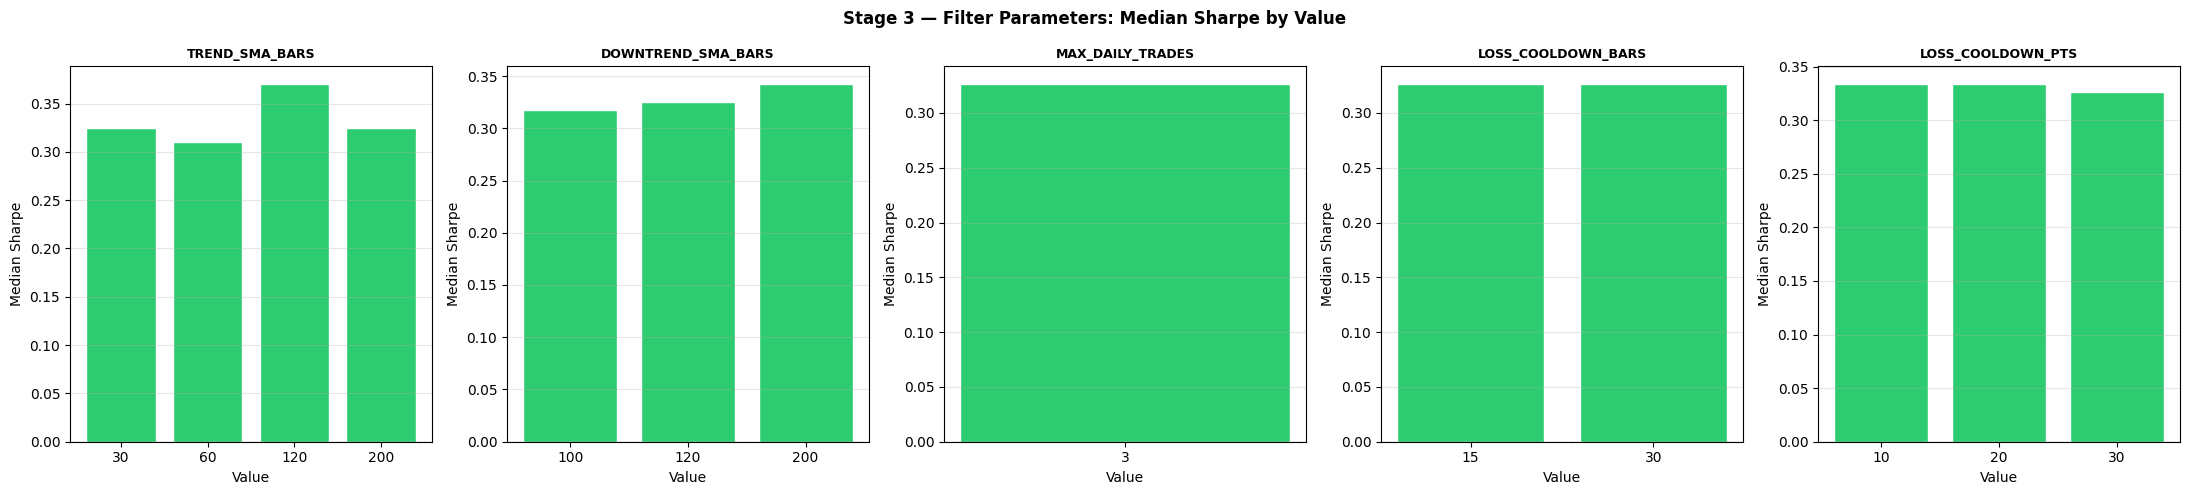

In [99]:
# Stage 3 sensitivity charts
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Stage 3 — Filter Parameters: Median Sharpe by Value', fontsize=12, fontweight='bold')

for ax, param in zip(axes, ['TREND_SMA_BARS','DOWNTREND_SMA_BARS','MAX_DAILY_TRADES',
                              'LOSS_COOLDOWN_BARS','LOSS_COOLDOWN_PTS']):
    vals    = sorted(stage3_df[param].unique())
    medians = [stage3_df.loc[stage3_df[param]==v, 'sharpe'].median() for v in vals]
    colors  = ['#2ecc71' if v > 0 else '#e74c3c' for v in medians]
    ax.bar([str(v) for v in vals], medians, color=colors, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(param, fontweight='bold', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Median Sharpe')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stage3_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()


In [100]:
best_s3_row = passing3.iloc[0]
for k in ['TREND_SMA_BARS','DOWNTREND_SMA_BARS','MAX_DAILY_TRADES',
          'LOSS_COOLDOWN_BARS','LOSS_COOLDOWN_PTS']:
    BEST[k] = best_s3_row[k]

print("=" * 55)
print("STAGE 3 RESULT — best filter parameters selected:")
print("=" * 55)
for k in ['TREND_SMA_BARS','DOWNTREND_SMA_BARS','MAX_DAILY_TRADES',
          'LOSS_COOLDOWN_BARS','LOSS_COOLDOWN_PTS']:
    print(f"  {k:<26} = {BEST[k]}")
print()
print(f"  In-sample Sharpe : {best_s3_row['sharpe']:+.4f}")
print(f"  N trades         : {int(best_s3_row['n'])}")
print(f"  Max drawdown     : {best_s3_row['max_dd']:.1f} NQ pts")


STAGE 3 RESULT — best filter parameters selected:
  TREND_SMA_BARS             = 120.0
  DOWNTREND_SMA_BARS         = 200.0
  MAX_DAILY_TRADES           = 3.0
  LOSS_COOLDOWN_BARS         = 15.0
  LOSS_COOLDOWN_PTS          = 20.0

  In-sample Sharpe : +0.4073
  N trades         : 13
  Max drawdown     : -99.8 NQ pts


In [101]:
BEST['TREND_SMA_BARS'] = int(BEST['TREND_SMA_BARS'])
BEST['DOWNTREND_SMA_BARS'] = int(BEST['DOWNTREND_SMA_BARS'])

## Section 7 — Stage 4: Position Sizing

Using all best parameters from Stages 1-3. Optimise volatility-targeted sizing.

VOL_TARGET = 0 falls back to FIXED_CONTRACTS = 1.
ATR scales the contract count inversely with recent volatility.

| Parameter | Grid |
|-----------|------|
| `VOL_TARGET` | 0.008, 0.016, 0.024, 0.032 |
| `ATR_WINDOW` | 10, 14, 20 |

In [102]:
VOL_TARGET_GRID = [0.008, 0.016, 0.024, 0.032]
ATR_WINDOW_GRID = [10, 14, 20]

stage4_rows = []
combos4 = list(product(VOL_TARGET_GRID, ATR_WINDOW_GRID))
total4  = len(combos4)

for k, (vt, aw) in enumerate(combos4):
    p = dict(BEST, VOL_TARGET=vt, ATR_WINDOW=aw)
    m = metrics(simulate(train_lib, p))
    stage4_rows.append(dict(VOL_TARGET=vt, ATR_WINDOW=aw, **m))
    print(f"  VOL_TARGET={vt:.3f}  ATR_WINDOW={aw:2d} -> "
          f"n={m['n']} sharpe={m['sharpe']:+.3f} "
          f"total={m['total']:+.0f} max_dd={m['max_dd']:+.0f}")

stage4_df = pd.DataFrame(stage4_rows)
print()
print(stage4_df[['VOL_TARGET','ATR_WINDOW','n','wr','sharpe','total','max_dd']].to_string(index=False))


  VOL_TARGET=0.008  ATR_WINDOW=10 -> n=13 sharpe=+0.392 total=+4558 max_dd=-596
  VOL_TARGET=0.008  ATR_WINDOW=14 -> n=13 sharpe=+0.379 total=+5449 max_dd=-647
  VOL_TARGET=0.008  ATR_WINDOW=20 -> n=13 sharpe=+0.388 total=+5599 max_dd=-710
  VOL_TARGET=0.016  ATR_WINDOW=10 -> n=13 sharpe=+0.402 total=+10539 max_dd=-1291
  VOL_TARGET=0.016  ATR_WINDOW=14 -> n=13 sharpe=+0.388 total=+11482 max_dd=-1475
  VOL_TARGET=0.016  ATR_WINDOW=20 -> n=13 sharpe=+0.395 total=+12013 max_dd=-1608
  VOL_TARGET=0.024  ATR_WINDOW=10 -> n=13 sharpe=+0.400 total=+16281 max_dd=-2096
  VOL_TARGET=0.024  ATR_WINDOW=14 -> n=13 sharpe=+0.391 total=+17421 max_dd=-2252
  VOL_TARGET=0.024  ATR_WINDOW=20 -> n=13 sharpe=+0.395 total=+18033 max_dd=-2515
  VOL_TARGET=0.032  ATR_WINDOW=10 -> n=13 sharpe=+0.406 total=+22622 max_dd=-2650
  VOL_TARGET=0.032  ATR_WINDOW=14 -> n=13 sharpe=+0.390 total=+23292 max_dd=-3003
  VOL_TARGET=0.032  ATR_WINDOW=20 -> n=13 sharpe=+0.394 total=+24278 max_dd=-3356

 VOL_TARGET  ATR_WIND

In [103]:
best_s4_row = stage4_df.sort_values('sharpe', ascending=False).iloc[0]
BEST['VOL_TARGET'] = float(best_s4_row['VOL_TARGET'])
BEST['ATR_WINDOW'] = int(best_s4_row['ATR_WINDOW'])

print("=" * 55)
print("STAGE 4 RESULT — best sizing parameters selected:")
print("=" * 55)
print(f"  VOL_TARGET  = {BEST['VOL_TARGET']}")
print(f"  ATR_WINDOW  = {BEST['ATR_WINDOW']}")


STAGE 4 RESULT — best sizing parameters selected:
  VOL_TARGET  = 0.032
  ATR_WINDOW  = 10


## Section 8 — Full Parameter Summary & In-Sample Backtest

In [104]:
print("=" * 60)
print("FINAL OPTIMISED PARAMETER SET")
print("=" * 60)
for k, v in BEST.items():
    print(f"  {k:<26} = {v}")
print()

# Run in-sample backtest with best params
is_trades = simulate(train_lib, BEST)
is_m      = metrics(is_trades)

print("IN-SAMPLE PERFORMANCE")
print("-" * 40)
print(f"  N trades         : {is_m['n']}")
print(f"  Win rate         : {is_m['wr']*100:.1f}%")
print(f"  Avg PnL / trade  : {is_m['avg']:+.2f} NQ pts (net)")
print(f"  Sharpe           : {is_m['sharpe']:+.4f}")
print(f"  Profit factor    : {is_m['pf']:.3f}")
print(f"  Total PnL        : {is_m['total']:+.1f} NQ pts (net)")
print(f"  Avg hold         : {is_m['avg_dur']:.1f} bars")
print(f"  Max drawdown     : {is_m['max_dd']:.1f} NQ pts")

# Exit reason breakdown
reasons = {}
for t in is_trades:
    reasons[t['reason']] = reasons.get(t['reason'], 0) + 1
print("\nExit reason breakdown:")
for r, cnt in sorted(reasons.items(), key=lambda x: -x[1]):
    print(f"  {r:<15} : {cnt:4d}  ({cnt/len(is_trades)*100:.1f}%)")


FINAL OPTIMISED PARAMETER SET
  CORR_WINDOW                = 15
  CORR_THRESHOLD             = 0.95
  MOM_LOOKBACK               = 20
  STD_THRESHOLD              = 1.5
  MIN_HOLD_BARS              = 5.0
  MAX_HOLD_BARS              = 60.0
  TRAIL_ACTIVATE_PTS         = 30.0
  TRAIL_DISTANCE_PTS         = 10.0
  MAX_DAILY_TRADES           = 3.0
  LOSS_COOLDOWN_PTS          = 20.0
  LOSS_COOLDOWN_BARS         = 15.0
  TREND_SMA_BARS             = 120
  DOWNTREND_SMA_BARS         = 200
  GAP_FILTER_PCT             = 0.002
  COOLDOWN_BARS              = 10
  VOL_TARGET                 = 0.032
  ATR_WINDOW                 = 10
  MIN_CONTRACTS              = 1
  MAX_CONTRACTS              = 40
  FIXED_CONTRACTS            = 1

IN-SAMPLE PERFORMANCE
----------------------------------------
  N trades         : 13
  Win rate         : 53.8%
  Avg PnL / trade  : +1740.15 NQ pts (net)
  Sharpe           : +0.4061
  Profit factor    : 6.631
  Total PnL        : +22622.0 NQ pts (net)
  Avg hold  

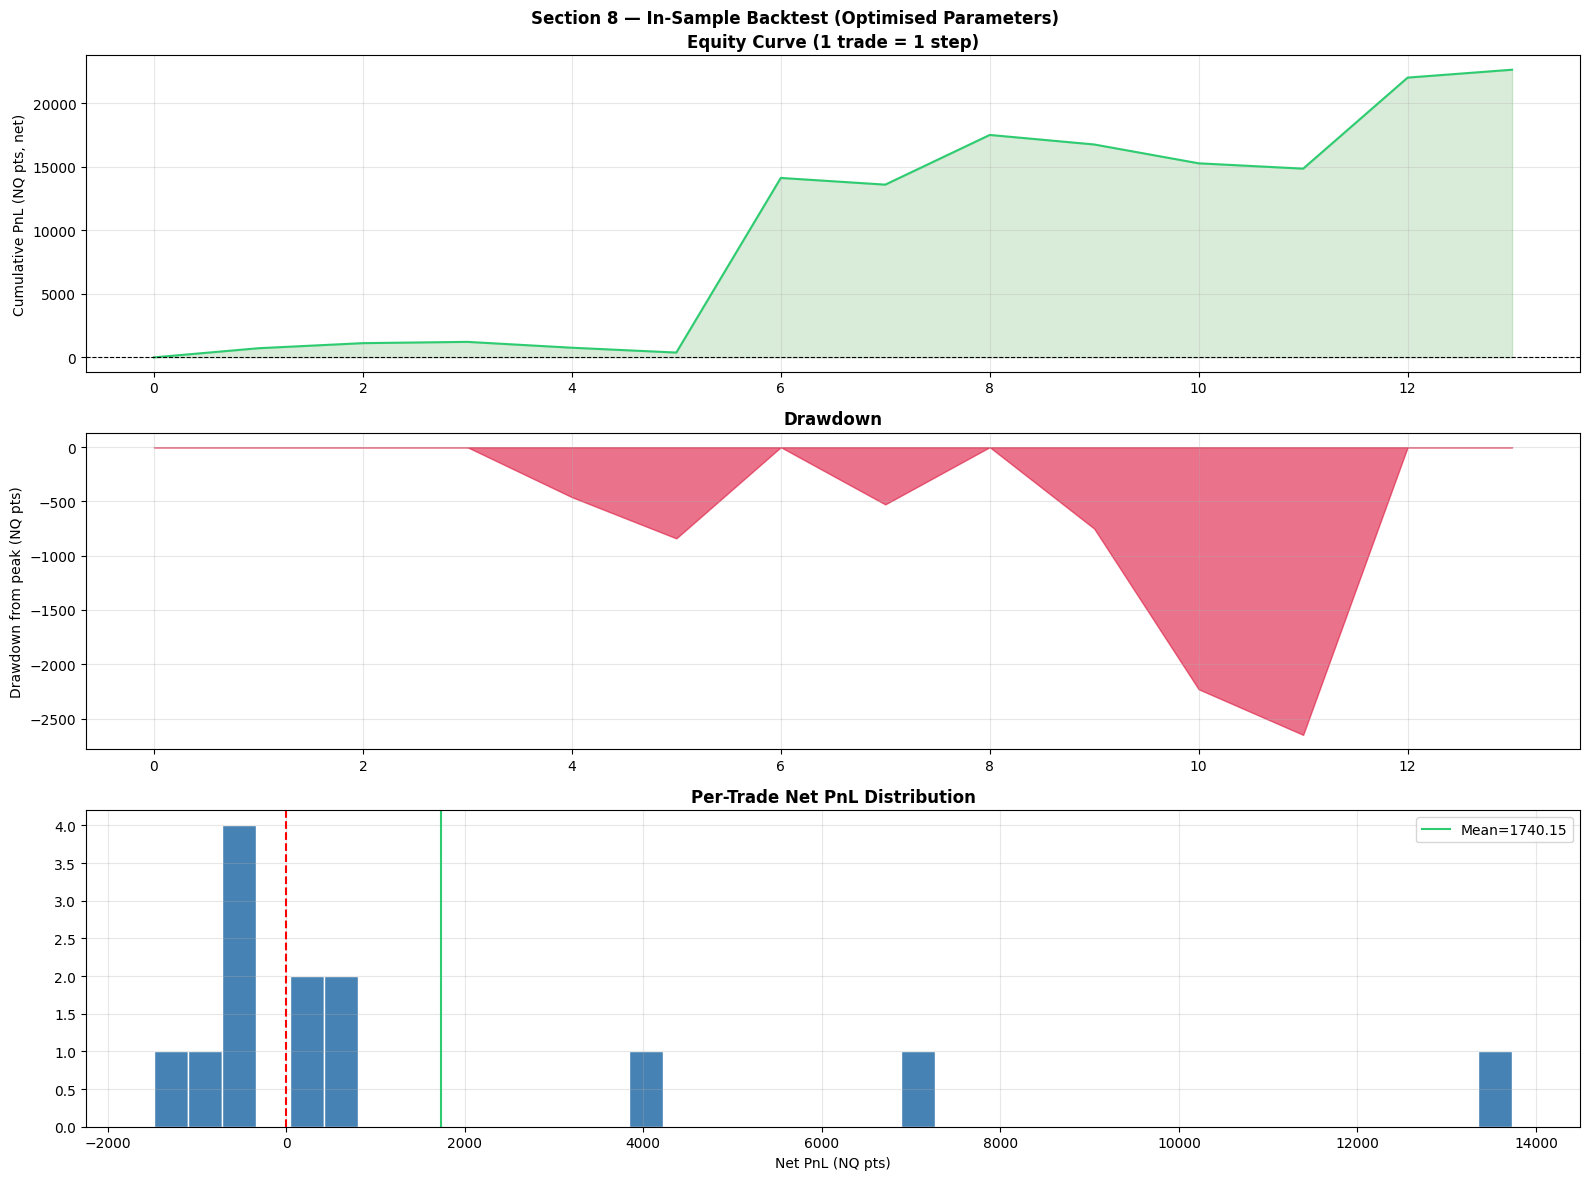

In [105]:
# In-sample equity curve + drawdown
net_pnls = [t['pnl_net'] for t in is_trades]
equity   = np.concatenate([[0], np.cumsum(net_pnls)])
peak     = np.maximum.accumulate(equity)
dd       = equity - peak

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Section 8 — In-Sample Backtest (Optimised Parameters)', fontweight='bold')

axes[0].plot(equity, color='#2ecc71', lw=1.5)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].fill_between(range(len(equity)), equity, 0,
                     where=equity >= 0, alpha=0.15, color='green')
axes[0].fill_between(range(len(equity)), equity, 0,
                     where=equity < 0, alpha=0.15, color='red')
axes[0].set_title('Equity Curve (1 trade = 1 step)', fontweight='bold')
axes[0].set_ylabel('Cumulative PnL (NQ pts, net)')
axes[0].grid(alpha=0.3)

axes[1].fill_between(range(len(dd)), dd, 0, alpha=0.6, color='crimson')
axes[1].set_title('Drawdown', fontweight='bold')
axes[1].set_ylabel('Drawdown from peak (NQ pts)')
axes[1].grid(alpha=0.3)

axes[2].hist([t['pnl_net'] for t in is_trades], bins=40,
             color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', lw=1.5, ls='--')
axes[2].axvline(np.mean([t['pnl_net'] for t in is_trades]),
                color='#2ecc71', lw=1.5, label=f"Mean={is_m['avg']:.2f}")
axes[2].set_title('Per-Trade Net PnL Distribution', fontweight='bold')
axes[2].set_xlabel('Net PnL (NQ pts)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('section8_is_backtest.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 9 — Out-of-Sample Validation

The test set (30 %) is used here for the first and only time.
Parameters are NOT modified based on these results.

Acceptance criterion: OOS Sharpe >= 50 % of in-sample Sharpe (generalisation check).

In [106]:
# Build test indicator library
print("Building test library...")
test_lib = build_indicator_library(test_df)
print(f"  {test_lib['n']:,} bars")

# Run OOS backtest with identical parameters
oos_trades = simulate(test_lib, BEST)
oos_m      = metrics(oos_trades)

print()
print("=" * 60)
print(f"{'Metric':<20}  {'In-Sample':>14}  {'Out-of-Sample':>14}")
print("-" * 60)
for key, label in [('n','N trades'), ('wr','Win rate'),
                   ('avg','Avg PnL/trade'), ('sharpe','Sharpe'),
                   ('pf','Profit factor'), ('total','Total PnL'),
                   ('avg_dur','Avg hold (bars)'), ('max_dd','Max drawdown')]:
    iv = is_m[key]
    ov = oos_m[key]
    if key == 'wr':
        print(f"  {label:<18}  {iv*100:>13.1f}%  {ov*100:>13.1f}%")
    else:
        def fmt(v): return f"{v:>14.4f}" if not np.isnan(v) else f"{'nan':>14}"
        print(f"  {label:<18}  {fmt(iv)}  {fmt(ov)}")
print("=" * 60)

# Generalisation check
if not np.isnan(is_m['sharpe']) and is_m['sharpe'] > 0 and not np.isnan(oos_m['sharpe']):
    ratio = oos_m['sharpe'] / is_m['sharpe']
    print(f"\n  OOS / IS Sharpe ratio : {ratio:.3f}")
    if ratio >= 0.5:
        print("  PASS: OOS Sharpe is >= 50% of IS. Generalisation is acceptable.")
    elif ratio >= 0.0:
        print("  MARGINAL: OOS Sharpe is positive but < 50% of IS. Possible overfit.")
    else:
        print("  FAIL: OOS Sharpe is negative. Strategy does not generalise.")
elif np.isnan(oos_m['sharpe']):
    print("  Cannot compute ratio: insufficient OOS trades.")


Building test library...
Pre-computing correlation arrays... done
Pre-computing z-score arrays... done
Pre-computing SMA arrays... done
Pre-computing ATR arrays... done
  204,475 bars

Metric                     In-Sample   Out-of-Sample
------------------------------------------------------------
  N trades                   13.0000          5.0000
  Win rate                     53.8%           60.0%
  Avg PnL/trade            1740.1538       1204.2000
  Sharpe                      0.4061          0.6071
  Profit factor               6.6309          4.7655
  Total PnL               22622.0000       6021.0000
  Avg hold (bars)             6.3846          6.4000
  Max drawdown            -2650.5000      -1010.0000

  OOS / IS Sharpe ratio : 1.495
  PASS: OOS Sharpe is >= 50% of IS. Generalisation is acceptable.


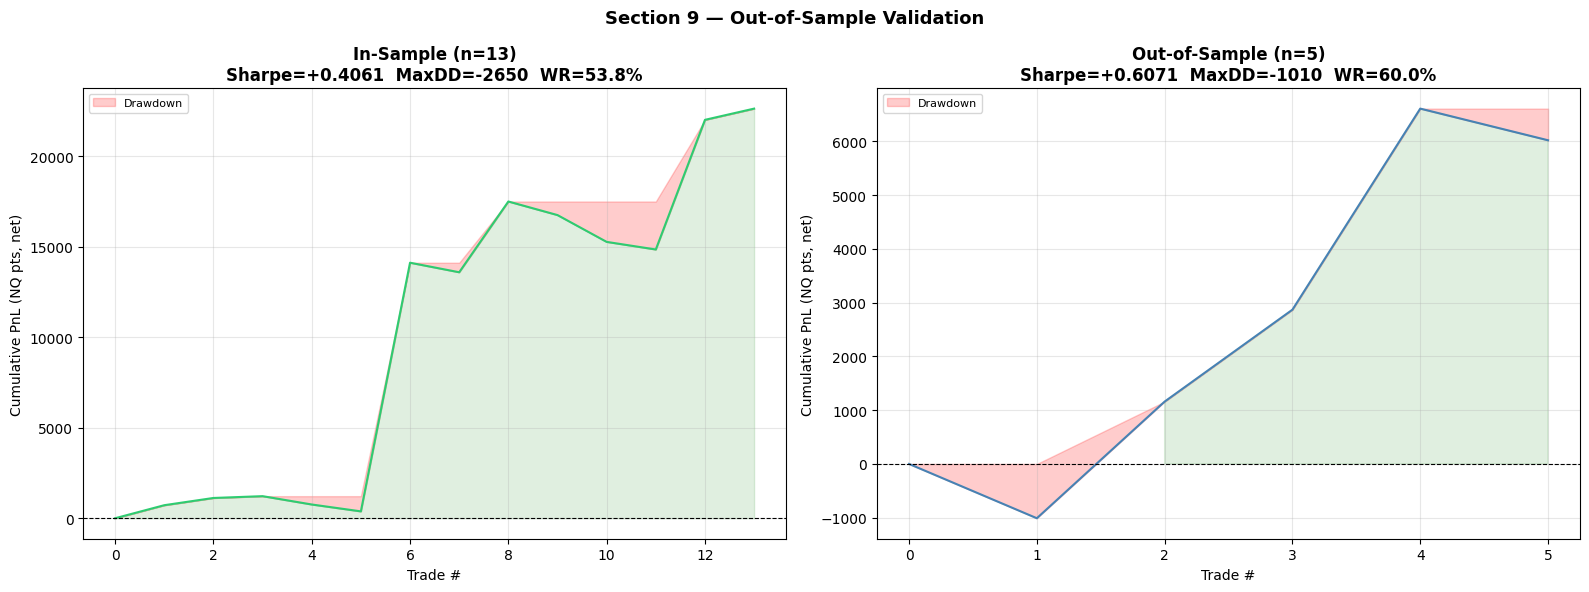

In [107]:
# OOS equity curve vs IS equity curve (normalised to % of trade count)
oos_pnls  = [t['pnl_net'] for t in oos_trades]
oos_eq    = np.concatenate([[0], np.cumsum(oos_pnls)])
is_eq     = equity   # computed in Section 8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 9 — Out-of-Sample Validation', fontsize=13, fontweight='bold')

for ax, eq, label, color in [
    (axes[0], is_eq,  f'In-Sample (n={is_m["n"]})',  '#2ecc71'),
    (axes[1], oos_eq, f'Out-of-Sample (n={oos_m["n"]})', 'steelblue'),
]:
    if len(eq) < 2:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center')
        continue
    m = is_m if 'is_eq' in str(eq) or eq is is_eq else oos_m
    m = is_m if color == '#2ecc71' else oos_m
    ax.plot(eq, color=color, lw=1.5)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    pk = np.maximum.accumulate(eq)
    ax.fill_between(range(len(eq)), eq, pk, alpha=0.2, color='red', label='Drawdown')
    ax.fill_between(range(len(eq)), eq, 0, where=eq >= 0, alpha=0.12, color='green')
    ax.set_title(
        f"{label}\nSharpe={m['sharpe']:+.4f}  MaxDD={m['max_dd']:.0f}  WR={m['wr']*100:.1f}%",
        fontweight='bold'
    )
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative PnL (NQ pts, net)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('section9_oos_validation.png', dpi=120, bbox_inches='tight')
plt.show()


In [108]:
# Final parameter table — copy into QC implementation
print("=" * 60)
print("FINAL STRATEGY SPECIFICATION")
print("Copy these into your QuantConnect algorithm.")
print("=" * 60)
for k, v in BEST.items():
    print(f"  self.{k:<26} = {v!r}")
print()
print("Performance summary:")
print(f"  In-sample  Sharpe : {is_m['sharpe']:+.4f}  (n={is_m['n']})")
print(f"  OOS        Sharpe : {oos_m['sharpe']:+.4f}  (n={oos_m['n']})")
if not np.isnan(is_m['sharpe']) and is_m['sharpe'] > 0:
    print(f"  OOS/IS ratio      : {oos_m['sharpe']/is_m['sharpe']:.3f}")


FINAL STRATEGY SPECIFICATION
Copy these into your QuantConnect algorithm.
  self.CORR_WINDOW                = 15
  self.CORR_THRESHOLD             = np.float64(0.95)
  self.MOM_LOOKBACK               = 20
  self.STD_THRESHOLD              = np.float64(1.5)
  self.MIN_HOLD_BARS              = np.float64(5.0)
  self.MAX_HOLD_BARS              = np.float64(60.0)
  self.TRAIL_ACTIVATE_PTS         = np.float64(30.0)
  self.TRAIL_DISTANCE_PTS         = np.float64(10.0)
  self.MAX_DAILY_TRADES           = np.float64(3.0)
  self.LOSS_COOLDOWN_PTS          = np.float64(20.0)
  self.LOSS_COOLDOWN_BARS         = np.float64(15.0)
  self.TREND_SMA_BARS             = 120
  self.DOWNTREND_SMA_BARS         = 200
  self.GAP_FILTER_PCT             = 0.002
  self.COOLDOWN_BARS              = 10
  self.VOL_TARGET                 = 0.032
  self.ATR_WINDOW                 = 10
  self.MIN_CONTRACTS              = 1
  self.MAX_CONTRACTS              = 40
  self.FIXED_CONTRACTS            = 1

Performance summ